# 02 – Prototype Autoencoder for AU Mic Spectra

In this notebook, I begin building and testing a convolutional autoencoder for the VIS_A spectra of AU Microscopii. Inspired by Mas-Buitrago et al. (2024), I aim to learn latent representations that capture variability across observations of a single star.

I will:
- Load and normalize the spectra from a selected spectral order.
- Define and train a 1D convolutional autoencoder.
- Visualize reconstructions and latent encodings.


In [2]:
import numpy as np
import os
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from astropy.io import fits

2025-04-07 22:35:35.407380: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-04-07 22:35:35.516536: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1744058135.561516   15553 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1744058135.575511   15553 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1744058135.657405   15553 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

In [3]:
fits_root = "../../aumicAE1"

with open("../data/carvis_visA/vis_a_files.txt", "r") as f:
    vis_a_files = [os.path.join(fits_root, line.strip().lstrip("../")) for line in f if line.strip()]

print(f"Loaded {len(vis_a_files)} resolved FITS file paths.")

Loaded 101 resolved FITS file paths.


In [4]:
with fits.open(vis_a_files[0]) as hdul:
    hdul.info()

Filename: ../../aumicAE1/data/AUMic/CARVIS/car-20190714T01h22m54s-sci-gtoc-vis_A.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     465   ()      
  1  SPEC          1 ImageHDU         8   (4096, 61)   float32   
  2  CONT          1 ImageHDU         8   (4096, 61)   float32   
  3  SIG           1 ImageHDU         8   (4096, 61)   float32   
  4  WAVE          1 ImageHDU         8   (4096, 61)   float64   


In [5]:
with fits.open(vis_a_files[0]) as hdul:
    print(hdul["SPEC"].data.shape)
    print(hdul["SPEC"].data[:, 30].shape)
    print(hdul["SPEC"].data[30, :].shape)

(61, 4096)
(61,)
(4096,)


## Select and Normalize One Spectral Order

For this prototype, I will work with spectral order 30. I normalize each spectrum by its continuum and clip extreme values.

In [6]:
def load_order_normalized(file_path, order_idx=30):
    with fits.open(file_path) as hdul:
        spec = hdul["SPEC"].data  
        cont = hdul["CONT"].data 

        flux = spec[order_idx, :]
        continuum = cont[order_idx, :]

        continuum = np.where(np.isfinite(continuum) & (continuum > 1e-3), continuum, 1.0)

        norm_flux = flux / continuum
        norm_flux = np.nan_to_num(norm_flux, nan=0.0, posinf=5.0, neginf=0.0)
        norm_flux = np.clip(norm_flux, 0.0, 5.0)

        return norm_flux.astype(np.float32)

## Prepare Input for Autoencoder

I reshape the data into tensors suitable for a 1D convolutional network.


In [7]:
spectra = [load_order_normalized(f) for f in vis_a_files]
spectra = np.stack(spectra)
X = spectra[..., np.newaxis]

print("Min:", np.min(X))
print("Max:", np.max(X))
print("Any NaNs?", np.isnan(X).any())
print("Any Infs?", np.isinf(X).any())

Min: 0.0
Max: 0.299978
Any NaNs? False
Any Infs? False


## Define the Autoencoder Architecture

I use a simple 1D convolutional autoencoder with a bottleneck latent layer. This will be refined in later versions.

In [8]:
def build_autoencoder(input_shape, latent_dim=8):
    inputs = layers.Input(shape=input_shape)

    x = layers.Conv1D(32, 5, activation="relu", padding="same")(inputs)
    x = layers.MaxPooling1D(2)(x)
    x = layers.Conv1D(16, 5, activation="relu", padding="same")(x)
    x = layers.MaxPooling1D(2)(x)

    x = layers.Flatten()(x)
    encoded = layers.Dense(latent_dim, name="latent")(x)

    x = layers.Dense((input_shape[0] // 4) * 16)(encoded)
    x = layers.Reshape((input_shape[0] // 4, 16))(x)

    x = layers.Conv1DTranspose(16, 5, activation="relu", padding="same")(x)
    x = layers.UpSampling1D(2)(x)
    x = layers.Conv1DTranspose(32, 5, activation="relu", padding="same")(x)
    x = layers.UpSampling1D(2)(x)
    outputs = layers.Conv1D(1, 3, activation="linear", padding="same")(x)

    return models.Model(inputs, outputs)

autoencoder = build_autoencoder((4096, 1))
autoencoder.compile(optimizer="adam", loss="mse")
autoencoder.summary()

2025-04-07 22:35:38.536858: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 4096, 1)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 4096, 32)       │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 2048, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 2048, 16)       │         2,576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 1024, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent (Dense)                  │ (None, 8)              │       131,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16384)          │       147,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 1024, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_transpose                │ (None, 1024, 16)       │         1,296 │
│ (Conv1DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling1d (UpSampling1D)    │ (None, 2048, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_transpose_1              │ (None, 2048, 32)       │         2,592 │
│ (Conv1DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling1d_1 (UpSampling1D)  │ (None, 4096, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 4096, 1)        │            97 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 285,289 (1.09 MB)

 Trainable params: 285,289 (1.09 MB)

 Non-trainable params: 0 (0.00 B)

## Train the Autoencoder

I train for a small number of epochs to check if the model learns a rough reconstruction.

In [9]:
history = autoencoder.fit(X, X, epochs=20, batch_size=8, validation_split=0.1)

Epoch 1/20
 4/12 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0107

2025-04-07 22:35:39.891195: E tensorflow/core/util/util.cc:131] oneDNN supports DT_INT32 only on platforms with AVX-512. Falling back to the default Eigen-based implementation if present.


12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - loss: 0.0084 - val_loss: 0.0016
Epoch 2/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0017 - val_loss: 9.1770e-04
Epoch 3/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 5.2909e-04 - val_loss: 5.4958e-04
Epoch 4/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 5.3158e-04 - val_loss: 6.1824e-04
Epoch 5/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 3.4241e-04 - val_loss: 3.2392e-04
Epoch 6/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 2.3309e-04 - val_loss: 2.1107e-04
Epoch 7/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 1.4805e-04 - val_loss: 1.9400e-04
Epoch 8/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 1.3469e-04 - val_loss: 1.6002e-04
Epoch 9/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 9.8076e-05 - val_loss: 1.3861e-04
Epoch 10/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 1.0223e-04 - val_loss: 1.4429e-04
Epoch 11/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 1.0912e-04 - val_loss: 1.0760e-0

## Visualize Reconstructions

Now I compare original and reconstructed spectra for a few examples.


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step


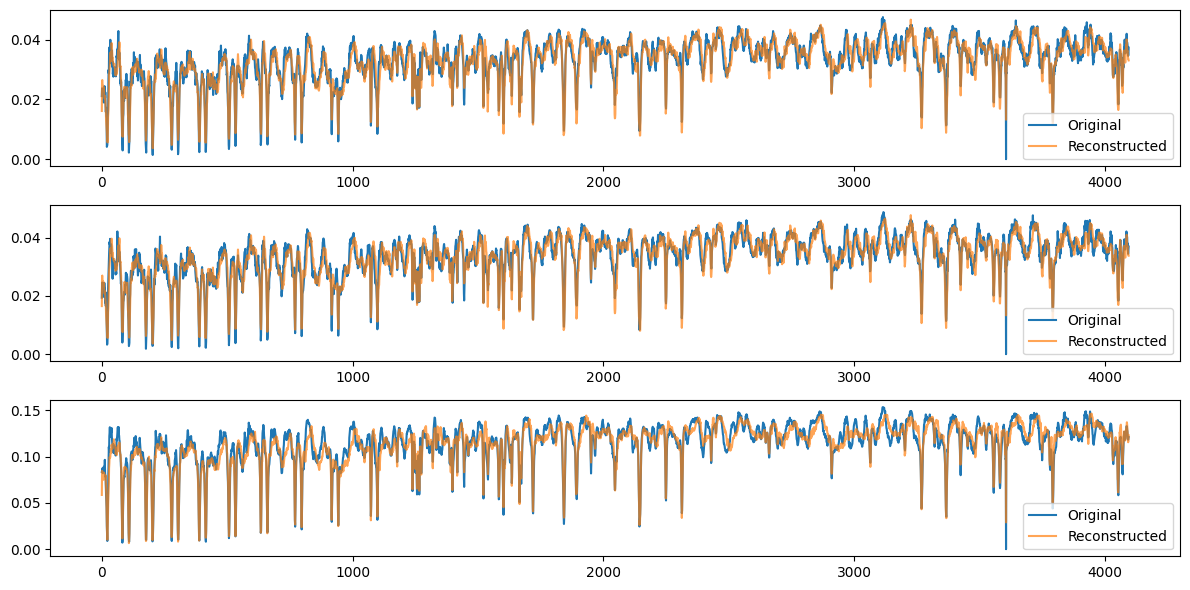

In [10]:
os.makedirs("../outputs/plots", exist_ok=True)

recon = autoencoder.predict(X)

n = 3
plt.figure(figsize=(12, 6))
for i in range(n):
    plt.subplot(n, 1, i + 1)
    plt.plot(X[i].squeeze(), label="Original")
    plt.plot(recon[i].squeeze(), label="Reconstructed", alpha=0.7)
    plt.legend()

plt.tight_layout()
plt.savefig("../outputs/plots/reconstruction_examples.png", dpi=150)
plt.show()

The plot shows that the autoencoder successfully reconstructs the overall shape and absorption features of the stellar spectra. While the reconstructed spectra closely follow the original ones, some fine details—especially sharp absorption lines—are slightly smoothed out. This indicates that the model has learned a good low-dimensional representation of the data, capturing the global spectral structure, but may still underfit high-frequency variations.

## Extract Latent Representations

I extract the compressed encoding of each spectrum from the bottleneck layer.


In [11]:
encoder = models.Model(autoencoder.input, autoencoder.get_layer("latent").output)
Z = encoder.predict(X)
print("Latent space shape:", Z.shape)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
Latent space shape: (101, 8)


So, we passed 101 spectra (shape: (101, 4096, 1)) into the encoder part of your autoencoder, where each was compressed into a latent vector of 8 values. Thus, the encoded output has shape (101 samples, 8 features).

##### Saving the latent vectors for this order (30):

In [12]:
os.makedirs("../outputs/latent", exist_ok=True)
np.save("../outputs/latent/latent_vectors_order30.npy", Z)
print("Saved latent vectors to ../outputs/latent/latent_vectors_order30.npy")

Saved latent vectors to ../outputs/latent/latent_vectors_order30.npy


## Next Steps

- Visualize the latent space over time
- Check correlations with known activity (e.g., flares, Hα lines)
- Compare latent dynamics with PCA
- Train with different orders or stacked multi-order inputs

→ Go to: `03_latent_analysis.ipynb`